# Real Estate Price Prediction Using Linear Regression

A machine learning project to predict house prices using property-related features.

### Models
- Simple Linear Regression
- Multiple Linear Regression
- Gradient Descent

### Evaluation Metrics
- MAE
- MSE
- RMSE
- R²

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme()
data = pd.read_csv("Real estate valuation data set.csv")

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 1. Dataset Overview

The dataset contains property-related information such as:

- Transaction date
- House age
- Distance to the nearest MRT station
- Number of convenience stores
- Latitude
- Longitude

The target variable is the house price of unit area.

In [7]:
print("Number of observations:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumns:")
print(data.columns.tolist())

data.info()

Number of observations: 414
Number of columns: 8

Columns:
['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area 

In [11]:
missing_values = data.isnull().sum()

print("Missing values:")
print(missing_values)

print("Number of duplicate rows:", data.duplicated().sum())

Missing values:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64
Number of duplicate rows: 0


In [12]:
data.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [13]:
data = data.drop(columns=["No"])

X = data.drop(columns=["Y house price of unit area"])
y = data["Y house price of unit area"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']

Target:
Y house price of unit area


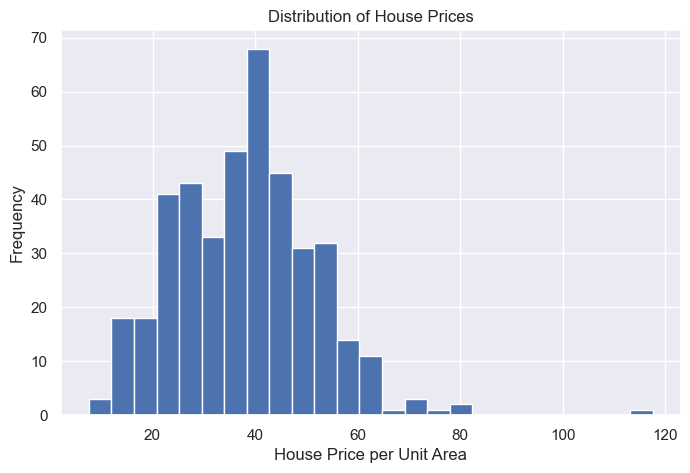

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=25)

plt.xlabel("House Price per Unit Area")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")

plt.show()

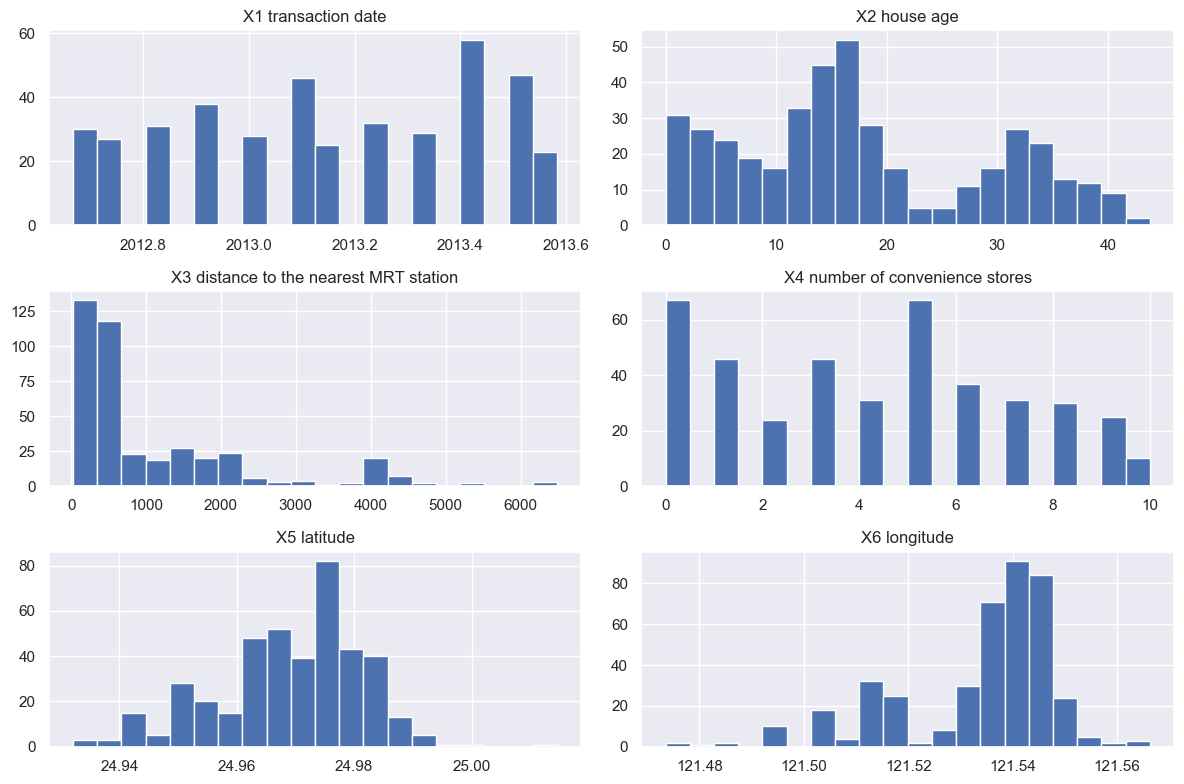

In [15]:
X.hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

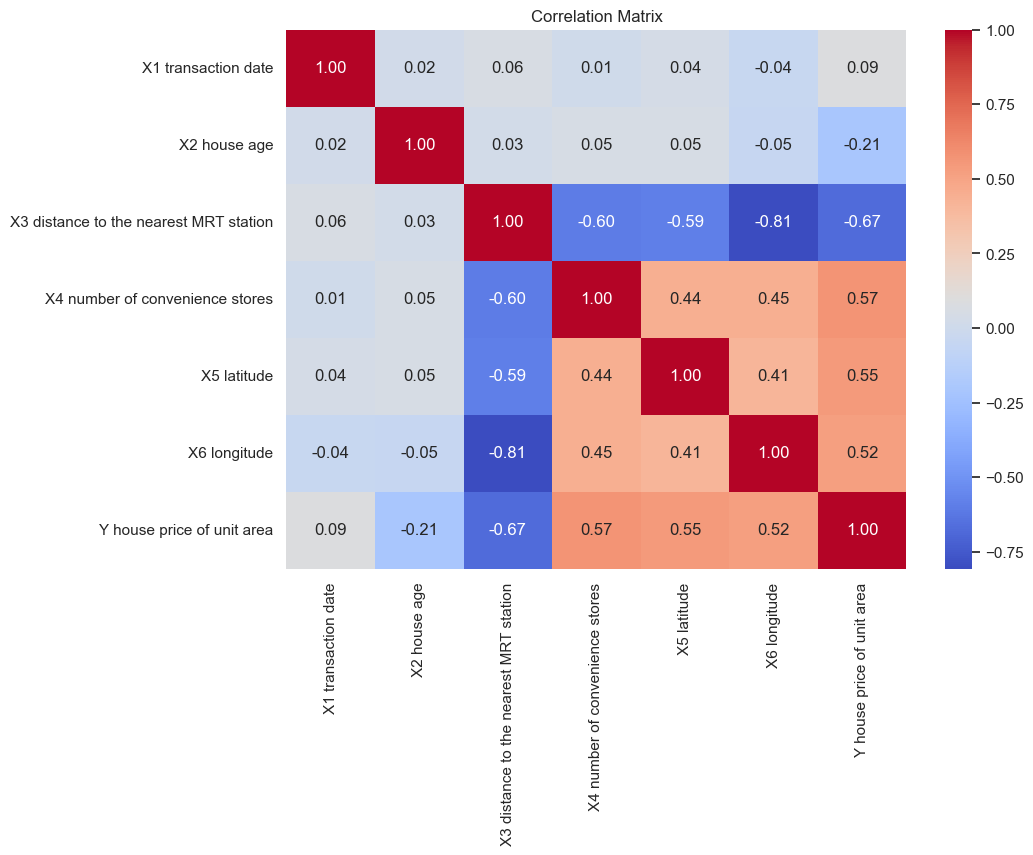

In [16]:
plt.figure(figsize=(10, 7))

correlation = data.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

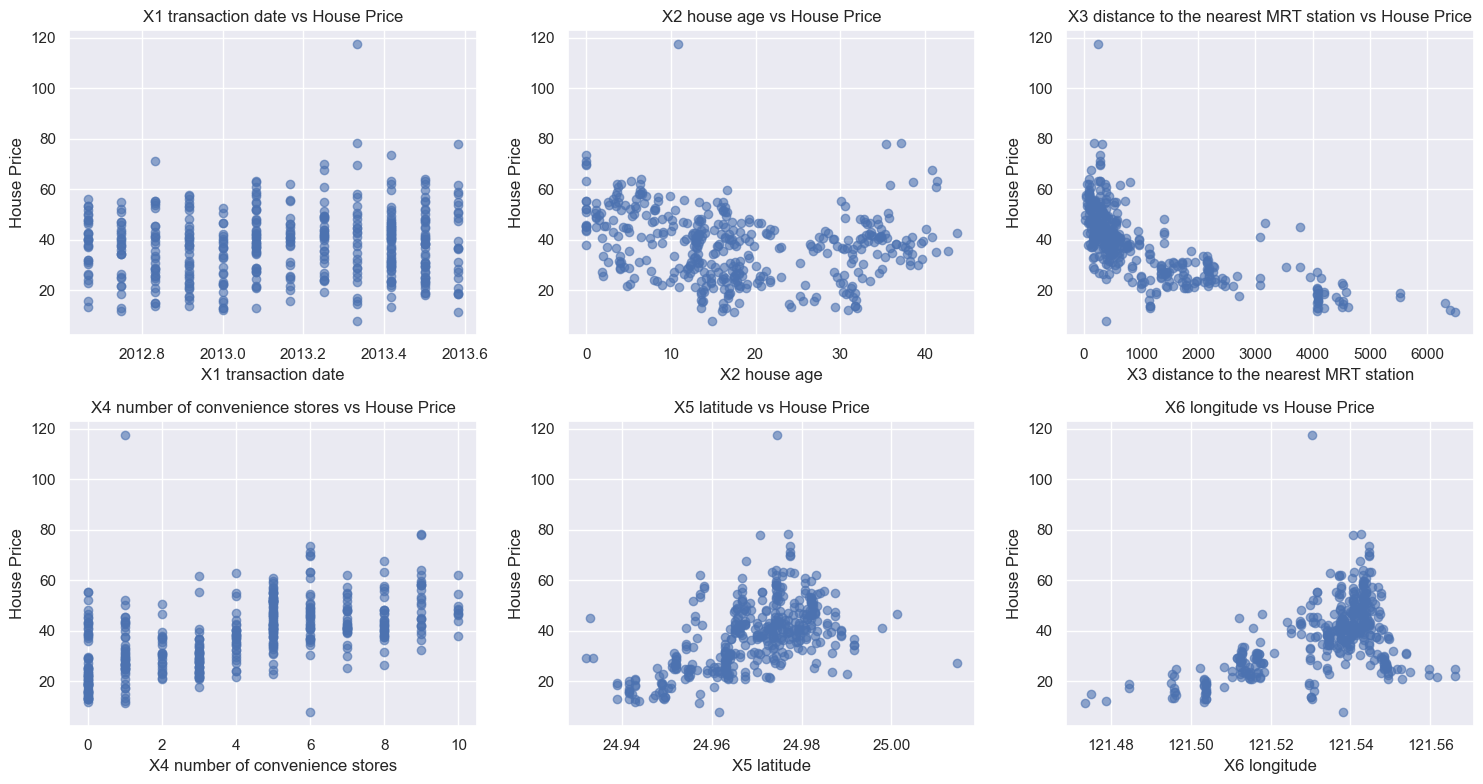

In [17]:
features = X.columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for feature, ax in zip(features, axes.flatten()):
    ax.scatter(X[feature], y, alpha=0.6)
    ax.set_xlabel(feature)
    ax.set_ylabel("House Price")
    ax.set_title(f"{feature} vs House Price")

plt.tight_layout()
plt.show()

In [18]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (data < lower_bound) |
    (data > upper_bound)
)

print("Possible outliers:")
print(outliers.sum())

Possible outliers:
X1 transaction date                        0
X2 house age                               0
X3 distance to the nearest MRT station    37
X4 number of convenience stores            0
X5 latitude                                8
X6 longitude                              35
Y house price of unit area                 3
dtype: int64


## 2. Data Preparation

The dataset is divided into training and testing sets.

80% of the data is used for training and 20% for testing.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

Training samples: 331
Testing samples: 83


## 3. Simple Linear Regression

We use the distance to the nearest MRT station as the single predictor.

This allows us to examine how one important feature relates to house price.

In [22]:
X_simple = X[["X3 distance to the nearest MRT station"]]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(
    X_train_simple,
    y_train_simple
)

y_pred_simple = simple_model.predict(X_test_simple)

print("Intercept:", simple_model.intercept_)
print("Coefficient:", simple_model.coef_)


Intercept: 46.24269004533652
Coefficient: -0.007409512934932927


In [23]:
simple_mae = mean_absolute_error(
    y_test_simple,
    y_pred_simple
)

simple_mse = mean_squared_error(
    y_test_simple,
    y_pred_simple
)

simple_rmse = np.sqrt(simple_mse)

simple_r2 = r2_score(
    y_test_simple,
    y_pred_simple
)

print("Simple Linear Regression")
print("------------------------")
print("MAE :", simple_mae)
print("MSE :", simple_mse)
print("RMSE:", simple_rmse)
print("R²  :", simple_r2)

Simple Linear Regression
------------------------
MAE : 6.920972703573579
MSE : 77.34399178518458
RMSE: 8.79454329599807
R²  : 0.5389597665019772


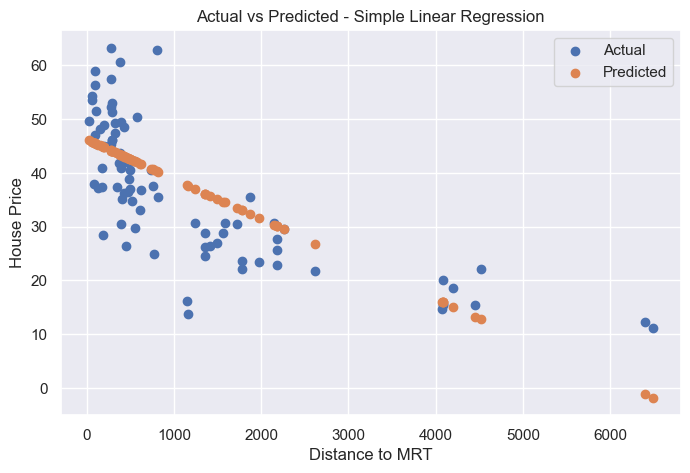

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_simple,
    y_test_simple,
    label="Actual"
)

plt.scatter(
    X_test_simple,
    y_pred_simple,
    label="Predicted"
)

plt.xlabel("Distance to MRT")
plt.ylabel("House Price")
plt.title("Actual vs Predicted - Simple Linear Regression")
plt.legend()

plt.show()

## 4. Multiple Linear Regression

Multiple Linear Regression uses all available property features to predict house price.

In [28]:
multiple_model = LinearRegression()

multiple_model.fit(
    X_train_scale,
    y_train
)

y_pred_multiple = multiple_model.predict(
    X_test_scale
)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_model.coef_
})

coefficients

,Feature,Coefficient
0,X1 transaction date,1.529631
1,X2 house age,-3.062694
2,X3 distance to the nearest MRT station,-5.786926
3,X4 number of convenience stores,3.218873
4,X5 latitude,2.855108
5,X6 longitude,-0.441009


In [29]:
multiple_mae = mean_absolute_error(
    y_test,
    y_pred_multiple
)

multiple_mse = mean_squared_error(
    y_test,
    y_pred_multiple
)

multiple_rmse = np.sqrt(multiple_mse)

multiple_r2 = r2_score(
    y_test,
    y_pred_multiple
)

print("Multiple Linear Regression")
print("--------------------------")
print("MAE :", multiple_mae)
print("MSE :", multiple_mse)
print("RMSE:", multiple_rmse)
print("R²  :", multiple_r2)

Multiple Linear Regression
--------------------------
MAE : 5.305355690074043
MSE : 53.50561912450208
RMSE: 7.314753524521662
R²  : 0.6810580555095945


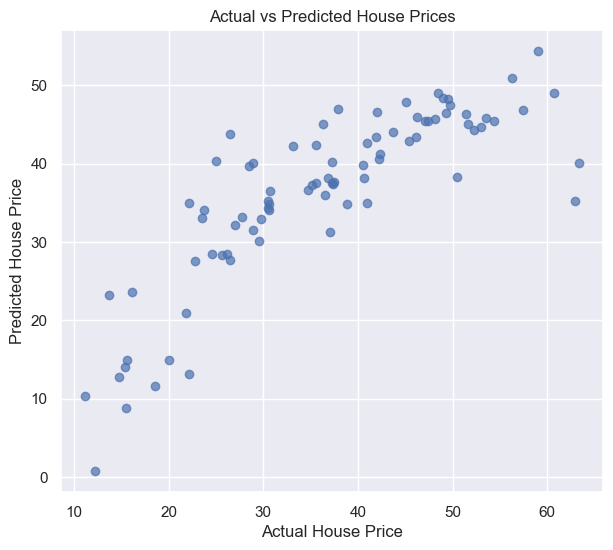

In [30]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_multiple,
    alpha=0.7
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

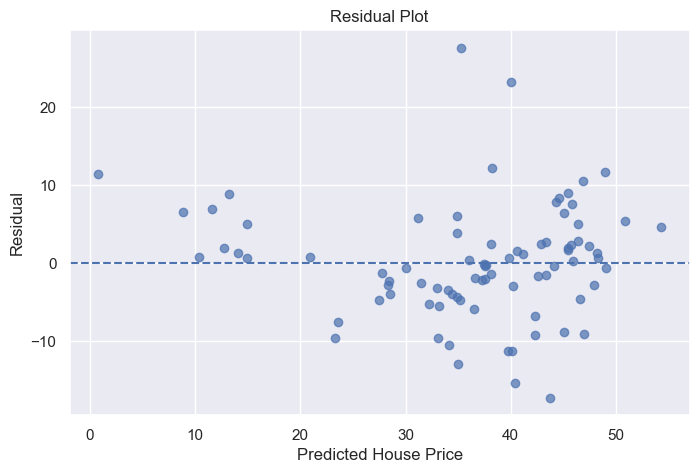

In [31]:
residuals = y_test - y_pred_multiple

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_multiple,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## 5. Linear Regression Using Gradient Descent

Gradient Descent is implemented from scratch to optimize the regression parameters.

Different learning rates are compared to observe their effect on convergence.

In [32]:
def gradient_descent(
    X,
    y,
    learning_rate=0.01,
    iterations=1000
):
    m, n = X.shape

    X_intercept = np.column_stack(
        [np.ones(m), X]
    )

    theta = np.zeros(n + 1)

    cost_history = []

    for _ in range(iterations):

        predictions = X_intercept @ theta

        error = predictions - y

        gradients = (
            X_intercept.T @ error
        ) / m

        theta -= learning_rate * gradients

        cost = np.sum(error ** 2) / (2 * m)

        cost_history.append(cost)

    return theta, cost_history

In [34]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:

    theta, cost_history = gradient_descent(
        X_train_scale,
        y_train.values,
        learning_rate=lr,
        iterations=1000
    )

    results[lr] = {
        "theta": theta,
        "cost_history": cost_history
    }

    print(
        f"Learning Rate: {lr} | "
        f"Final Cost: {cost_history[-1]:.4f}"
    )

Learning Rate: 0.001 | Final Cost: 143.6832
Learning Rate: 0.01 | Final Cost: 41.6017
Learning Rate: 0.1 | Final Cost: 41.5567


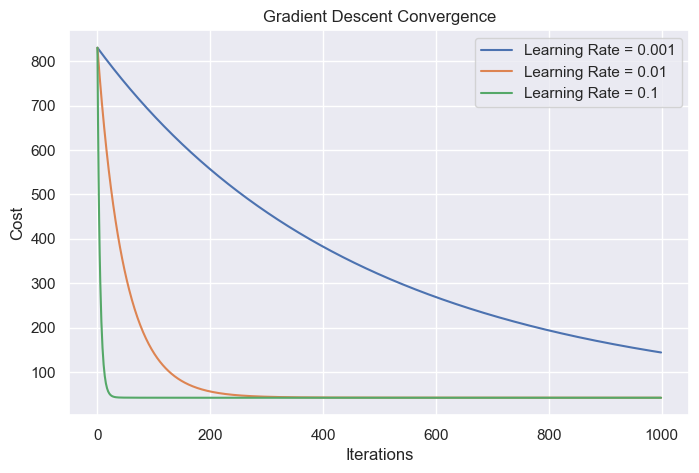

In [35]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:

    plt.plot(
        results[lr]["cost_history"],
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.legend()

plt.show()

In [38]:
best_lr = 0.1

theta_gd = results[best_lr]["theta"]

X_test_intercept = np.column_stack(
    [np.ones(len(X_test_scale)), X_test_scale]
)

y_pred_gd = X_test_intercept @ theta_gd

gd_mae = mean_absolute_error(
    y_test,
    y_pred_gd
)

gd_mse = mean_squared_error(
    y_test,
    y_pred_gd
)

gd_rmse = np.sqrt(gd_mse)

gd_r2 = r2_score(
    y_test,
    y_pred_gd
)

print("Multiple Linear Regression - Gradient Descent")
print("-----------------------------------------------")
print("MAE :", gd_mae)
print("MSE :", gd_mse)
print("RMSE:", gd_rmse)
print("R²  :", gd_r2)

Multiple Linear Regression - Gradient Descent
-----------------------------------------------
MAE : 5.305355669249643
MSE : 53.50561889248052
RMSE: 7.314753508661828
R²  : 0.6810580568926532


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Multiple Linear Regression - Gradient Descent"
    ],
    
    "MAE": [
        simple_mae,
        multiple_mae,
        gd_mae
    ],
    
    "MSE": [
        simple_mse,
        multiple_mse,
        gd_mse
    ],
    
    "RMSE": [
        simple_rmse,
        multiple_rmse,
        gd_rmse
    ],
    
    "R²": [
        simple_r2,
        multiple_r2,
        gd_r2
    ]
})

print(comparison.round(4))

                                           Model     MAE      MSE    RMSE  \
0                       Simple Linear Regression  6.9210  77.3440  8.7945   
1                     Multiple Linear Regression  5.3054  53.5056  7.3148   
2  Multiple Linear Regression - Gradient Descent  5.3054  53.5056  7.3148   

       R²  
0  0.5390  
1  0.6811  
2  0.6811  


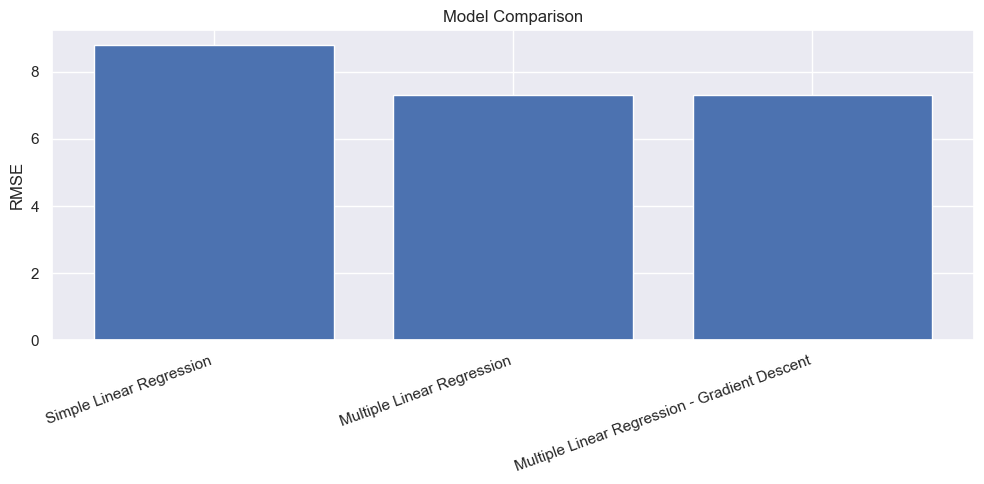

In [43]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Model Comparison")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

In [44]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print("Best model based on RMSE:")
print(best_model["Model"])

print("\nRMSE:", round(best_model["RMSE"], 4))
print("R²:", round(best_model["R²"], 4))

Best model based on RMSE:
Multiple Linear Regression - Gradient Descent

RMSE: 7.3148
R²: 0.6811


## 6. Conclusion

This project explored house-price prediction using Linear Regression.

The workflow included:

- Data cleaning and validation
- Exploratory data analysis
- Correlation analysis
- Outlier detection
- Train-test splitting
- Feature scaling
- Simple Linear Regression
- Multiple Linear Regression
- Gradient Descent from scratch
- Model evaluation and comparison

The models were evaluated using MAE, MSE, RMSE and R².

The final model was selected based on the lowest RMSE on the held-out test set.